---
title: Linear Regression
author: Andrei Akopian
date: 2026-02-14
format:
  html:
    code-fold: true
    code-summary: "Show the code"
  pdf:
    code-overflow: wrap
    echo: false
    output: true
---

Baseline linear regression for unmixing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sklearn

In [3]:
# Sys and self defs Imports
import sys
from pathlib import Path

github_root = Path.cwd().resolve().parents[1]
sys.path.append(str(github_root))

from src.utils import helper_functions

In [5]:
DATA_FILEPATH = "../../data/useful_columns_data.csv"

In [6]:
df = helper_functions.open_file(DATA_FILEPATH)
fractions, nr900to1700 = helper_functions.take_subset(df,start=900,end=1700)

# Naive Linear Regression

A naive linear regression, without adjusting to the specifics of the dataset in anyway.

In [7]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1700, fractions, test_size=0.5, random_state=42)
naive_regression = sklearn.linear_model.LinearRegression()
naive_regression.fit(X_train, y_train) # should train in 0.1s on modern hardware

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Naive linear regression sticks outside of the [0, 1] range.

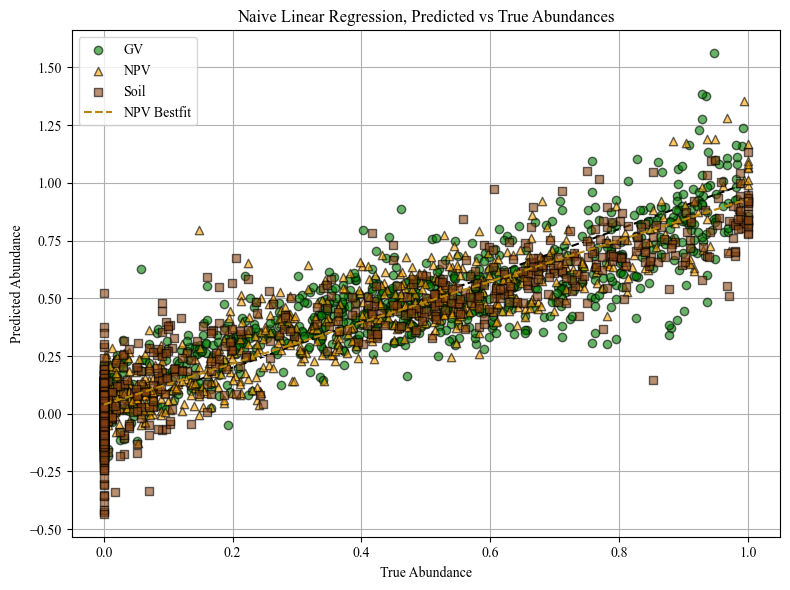

npv r^2 = 0.7477838848356202
gv r^2 = 0.8606047077387966
soil r^2 = 0.8472451032858296
mean r^2 = 0.8185445652867488


In [23]:
ab_true_np_array = y_test.to_numpy()
ab_predictions = naive_regression.predict(X_test)
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_predictions,
    model_name="Naive Linear Regression",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")

We clip the predicted abundances to [0,1] range, and visually confirm that the fractions add up roughly to 1.

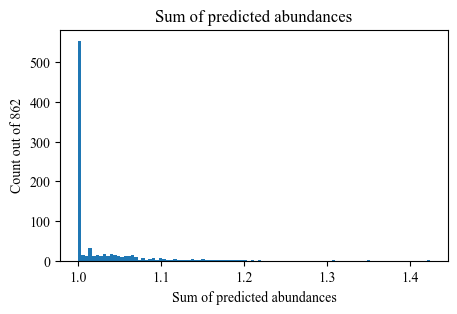

In [9]:
# | output: false
# | code-fold: true
ab_clipped_predictions = np.clip(ab_predictions, a_min=0, a_max=1)
helper_functions.simple_histogram(ab_clipped_predictions.sum(axis=1), title="Sum of predicted abundances", x_label="Sum of predicted abundances", y_label=f"Count out of {y_test.shape[0]}", bins=100)

Clipped prediction plot:

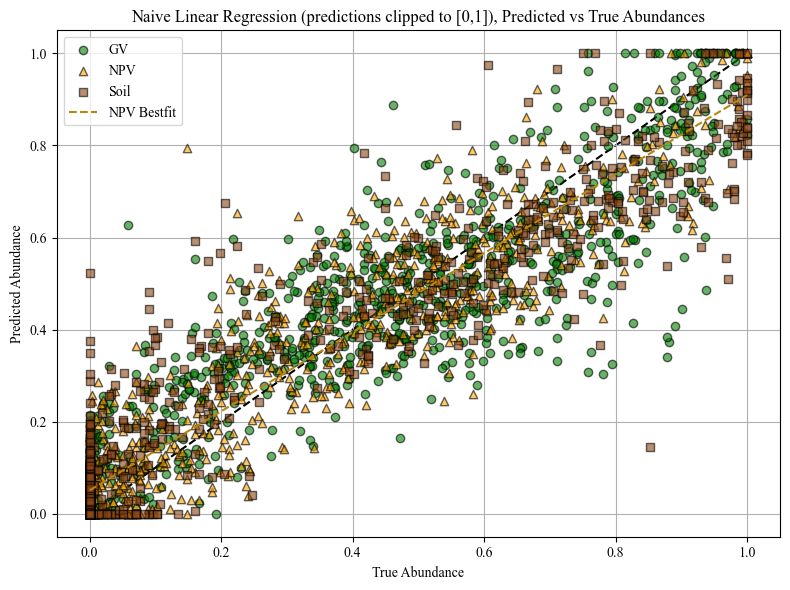

npv r^2 = 0.7683050213107616
gv r^2 = 0.870577266343572
soil r^2 = 0.8877600900948718
mean r^2 = 0.8422141259164019


In [24]:
helper_functions.plot_preds(
    ab_true=ab_true_np_array,
    ab_pred=ab_clipped_predictions,
    model_name="Naive Linear Regression (predictions clipped to [0,1])",
    save_path="naive_linear_regression_pred_plot.svg"
)
slope, intercept, r, p, se = scipy.stats.linregress(ab_true_np_array, ab_clipped_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")

# Better Linear Regression

The naive linear regression, has a number of drawbacks, such as forcing values to be clipped.

Also, naive linear regression ignored rows that were missing one of the 3 abundances. ([See `dataset_characterization.ipynb`](../characterization/dataset_characterization.ipynb))

This linear regression model will:
- train the abundanees separately, only using
- transform the results using a logit function into the [0, 1] range instead of clipping

In [11]:
logit = lambda x: scipy.special.logit((x-np.float64(0.5))*np.float64(0.90)+np.float64(0.5))
expit = scipy.special.expit

In [12]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(nr900to1700, fractions, test_size=0.5, random_state=42)

npv_indecies = {i for i, value in enumerate(df['has_npv']) if value}
gv_indecies = {i for i, value in enumerate(df['has_gv']) if value}
soil_indecies = {i for i, value in enumerate(df['has_soil']) if value}
training_indecies = set(X_train.index)

# fit regressions
npv_train_indecies = list(training_indecies.intersection(npv_indecies))
npv_regression = sklearn.linear_model.LinearRegression()
npv_train = logit(y_train.loc[npv_train_indecies]['npv_fraction'].to_numpy())
npv_regression.fit(X_train.loc[npv_train_indecies], npv_train)

gv_train_indecies = list(training_indecies.intersection(gv_indecies))
gv_regression = sklearn.linear_model.LinearRegression()
gv_train = logit(y_train.loc[gv_train_indecies]['gv_fraction'].to_numpy())
gv_regression.fit(X_train.loc[gv_train_indecies], gv_train)

soil_train_indecies = list(training_indecies.intersection(soil_indecies))
soil_regression = sklearn.linear_model.LinearRegression()
soil_train = logit(y_train.loc[soil_train_indecies]['soil_fraction'].to_numpy())
soil_regression.fit(X_train.loc[soil_train_indecies], soil_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
testing_indecies = X_test.index
prediction_buffer = np.array([[0.0,0.0,0.0] for i in testing_indecies])
npv_preds = expit(npv_regression.predict(X_test))
gv_preds = expit(gv_regression.predict(X_test))
soil_preds = expit(soil_regression.predict(X_test))

for i, index in enumerate(testing_indecies):
    if index in npv_indecies:
        prediction_buffer[i][0] = npv_preds[i]
    if index in gv_indecies:
        prediction_buffer[i][1] = np.float64(gv_preds[i])
    if index in soil_indecies:
        prediction_buffer[i][2] = np.float64(soil_preds[i])
        

In [16]:
# | output: false
# | code-fold: true
sums = np.sum(prediction_buffer, axis=1)
ab_clipnormed_predictions = np.array([prediction_buffer[i]/s for i, s in enumerate(sums)])
print(ab_clipnormed_predictions.sum(axis=1).min(), ab_clipnormed_predictions.sum(axis=1).max())

0.9999999999999998 1.0000000000000002


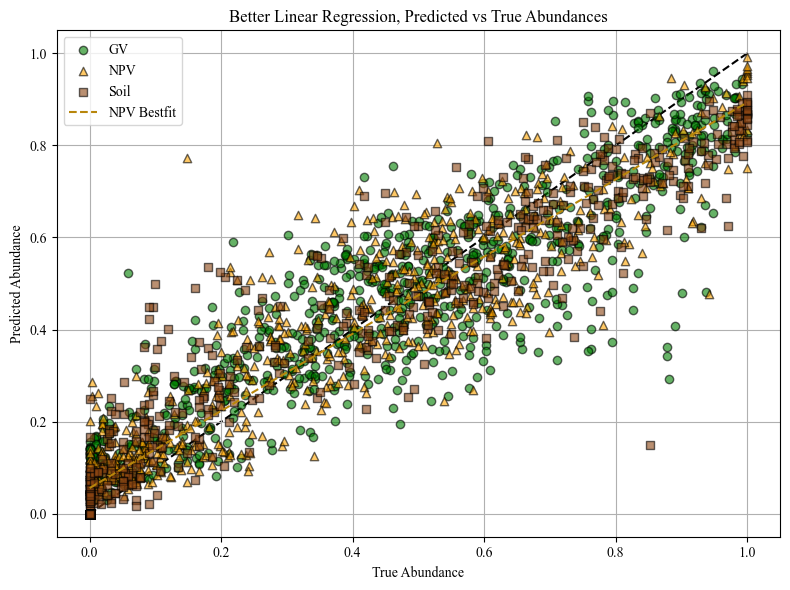

npv r^2 = 0.8091350754685501
gv r^2 = 0.8779800793644162
soil r^2 = 0.9278389812330042
mean r^2 = 0.8716513786886568


In [25]:
helper_functions.plot_preds(
    ab_true=y_test.to_numpy(), 
    ab_pred=ab_clipnormed_predictions, 
    save_path="better_linear_regression.svg",
    model_name="Better Linear Regression"
)
slope, intercept, r, p, se = scipy.stats.linregress(y_test.to_numpy(), ab_clipnormed_predictions)
print(f"npv r^2 = {r[0]**2}")
print(f"gv r^2 = {r[1]**2}")
print(f"soil r^2 = {r[2]**2}")
print(f"mean r^2 = {np.square(r).mean()}")